# Validation: do other tools agree on the coordinates?

prot2exon takes a protein domain (an amino-acid range) and reports the exact
genomic bases that code it. The way to trust those coordinates is simple: run
the same queries through tools people already rely on and check everyone lands
on the **same** genomic positions. If they all agree, the mapping is right.

This notebook does that **live**: it runs four tools on a small set of queries
and compares their answers, so you can reproduce the check yourself instead of
taking a number on faith.

- **prot2exon** (this tool): maps from a pre-built index in microseconds.
- **ensembldb::proteinToGenome**: the standard R/Bioconductor tool.
- **GenomicFeatures::proteinToGenome**: a second R/Bioconductor method.
- **Ensembl REST API**: Ensembl's public web service, nothing to install.

The two R tools need R plus the `EnsDb.Hsapiens.v86` package; the REST step needs
internet. Any tool whose requirements are missing is skipped with a note, and
the others still run.

## Setup

`N_QUERIES` sets how many queries each tool maps. Keep it small: the R tools and
the rate-limited REST API are slow (the published headline used 5,000 queries
and took hours for ensembldb). 100 queries finishes in a couple of minutes and
is plenty to show agreement. Each step caches its output to `WORK`, so
re-running the notebook reuses results; delete those files to recompute.

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, sys, subprocess, time
from shutil import which
from pathlib import Path
import pandas as pd

N_QUERIES = 100   # raise for a stricter (slower) check

# Find the repo so we can call the binary and the benchmark scripts.
# Set PROT2EXON_REPO if you run this from outside a checkout (e.g. Colab).
start = Path.cwd()
_repo_env = os.environ.get("PROT2EXON_REPO")
REPO = Path(_repo_env) if _repo_env else next(
    (p for p in [start, *start.parents]
     if (p / "benchmarks" / "compare_intervals.py").exists()), start)
DATA = Path(os.environ.get("PROT2EXON_DATA", Path.home() / "Desktop" / "protein2genomic_data"))
BIN = REPO / "build" / "prot2exon"
INDEX = DATA / "human_v86.idx"          # Ensembl v86 index (matches EnsDb.Hsapiens.v86)
ALL_QUERIES = DATA / "queries_v86.bed"  # cols: protein_id, aa_start, aa_end, query_id
WORK = DATA / "notebook_validation"; WORK.mkdir(parents=True, exist_ok=True)

# Our working set is the first N_QUERIES of the stratified query file.
qset = WORK / f"queries_{N_QUERIES}.bed"
with open(ALL_QUERIES) as fin, open(qset, "w") as fout:
    for i, line in enumerate(fin):
        if i >= N_QUERIES: break
        fout.write(line)
print(f"repo  : {REPO}")
print(f"using : {N_QUERIES} queries from {ALL_QUERIES.name}")

def ensdb_path():
    r = subprocess.run(["Rscript", "-e",
        'cat(system.file("extdata/EnsDb.Hsapiens.v86.sqlite", package=\"EnsDb.Hsapiens.v86\"))'],
        capture_output=True, text=True)
    return r.stdout.strip()

repo  : /home/goguxor/Desktop/protein2genomic
using : 100 queries from queries_v86.bed


## Tool 1: prot2exon

prot2exon loads its pre-built index once, then maps every query in a single
pass. The `domain_cds_segments.tsv` it writes lists, per query, the genomic
coordinates of the CDS pieces that code the domain.

In [2]:
p2e_out = WORK / "p2e"
t0 = time.time()
subprocess.run([str(BIN), "map", "--index", str(INDEX), "--bed", str(qset),
                "--out-dir", str(p2e_out), "--output", "all"],
               check=True, capture_output=True, text=True)
print(f"prot2exon mapped {N_QUERIES} queries in {time.time()-t0:.2f} s")

prot2exon mapped 100 queries in 1.26 s


## Tool 2: ensembldb::proteinToGenome (R / Bioconductor)

ensembldb is the long-standing Bioconductor tool for this job. It keeps the
annotation in a SQLite database (an EnsDb) and looks up each protein's exon
structure there. The helper `tutorial/reproduce_paper/benchmarks/proteintogenome_bench.R` drives it and
writes the genomic intervals in a shared format. Needs R; skipped otherwise.

In [3]:
ens_tsv = WORK / "ens_intervals.tsv"
if not which("Rscript"):
    print("Rscript not found; skipping ensembldb (install R + EnsDb.Hsapiens.v86 to include it).")
elif ens_tsv.exists():
    print("using cached", ens_tsv.name)
else:
    t0 = time.time()
    subprocess.run(["Rscript", str(REPO/"benchmarks"/"proteintogenome_bench.R"),
                    "ensembldb", ensdb_path(), str(qset), str(ens_tsv), str(WORK/"ens_timing.tsv")],
                   check=True, capture_output=True, text=True)
    print(f"ensembldb mapped {N_QUERIES} queries in {time.time()-t0:.1f} s")

using cached ens_intervals.tsv


## Tool 3: GenomicFeatures::proteinToGenome (R / Bioconductor)

`proteinToGenome` also ships in a second package, GenomicFeatures. Instead of
querying SQLite on every call, it builds an in-memory table of CDS-by-transcript
once and maps against that. Same idea, different engine, which makes it a good
independent check. Same R requirement as above.

In [4]:
gf_tsv = WORK / "gf_intervals.tsv"
if not which("Rscript"):
    print("Rscript not found; skipping GenomicFeatures.")
elif gf_tsv.exists():
    print("using cached", gf_tsv.name)
else:
    t0 = time.time()
    subprocess.run(["Rscript", str(REPO/"benchmarks"/"proteintogenome_bench.R"),
                    "genomicfeatures", ensdb_path(), str(qset), str(gf_tsv), str(WORK/"gf_timing.tsv")],
                   check=True, capture_output=True, text=True)
    print(f"GenomicFeatures mapped {N_QUERIES} queries in {time.time()-t0:.1f} s")

using cached gf_intervals.tsv


## Tool 4: Ensembl REST API

The Ensembl REST API answers the same question over the web, with nothing to
install. The trade-off is speed: the public server is rate-limited, so this is
the slowest option here. `tutorial/reproduce_paper/benchmarks/run_ensembl_rest.py` sends one request per
query and writes the intervals in the same shared format. Needs internet.

In [5]:
rest_tsv = WORK / "rest_intervals.tsv"
if rest_tsv.exists():
    print("using cached", rest_tsv.name)
else:
    try:
        t0 = time.time()
        subprocess.run([sys.executable, str(REPO/"benchmarks"/"run_ensembl_rest.py"),
                        str(qset), str(rest_tsv)],
                       check=True, capture_output=True, text=True, timeout=900)
        print(f"Ensembl REST mapped {N_QUERIES} queries in {time.time()-t0:.0f} s")
    except Exception as e:
        print("REST step skipped (no internet or rate-limited):", str(e)[:120])

using cached rest_intervals.tsv


## Do they agree?

Each tool reduces every query to a set of genomic segments. Two tools agree on a
query when those sets are identical. We load each tool's output with the loader
in `tutorial/reproduce_paper/benchmarks/compare_intervals.py` and count, for every other tool, the share
of shared queries where it matches prot2exon exactly.

We compare the `(chromosome, start, end)` of each segment. Strand is left out
of the check because the Ensembl REST endpoint does not report a per-segment
strand (it returns `.`), while the coordinates it returns are the same ones the
other tools produce.

In [6]:
sys.path.insert(0, str(REPO/"benchmarks"))
import compare_intervals as ci
import importlib; importlib.reload(ci)

def coords(segments):
    # Drop strand: {(chrom, start, end, strand)} -> {(chrom, start, end)}
    return {(c, s, e) for (c, s, e, _strand) in segments}

p2e = {q: coords(v) for q, v in ci.load_prot2exon(p2e_out/"domain_cds_segments.tsv").items()}
rows = []
for name, path in [("ensembldb", ens_tsv), ("GenomicFeatures", gf_tsv), ("Ensembl REST", rest_tsv)]:
    if not path.exists():
        continue
    other = {q: coords(v) for q, v in ci.load_rgranges(path).items()}
    common = set(p2e) & set(other)
    agree = sum(1 for q in common if p2e[q] == other[q])
    rows.append({"tool": name, "shared_queries": len(common), "exact_match": agree,
                 "exact_pct": 100*agree/len(common) if common else float("nan")})
agreement = pd.DataFrame(rows)
agreement

,tool,shared_queries,exact_match,exact_pct
0,ensembldb,100,100,100.000000
1,GenomicFeatures,100,100,100.000000
2,Ensembl REST,90,82,91.111111


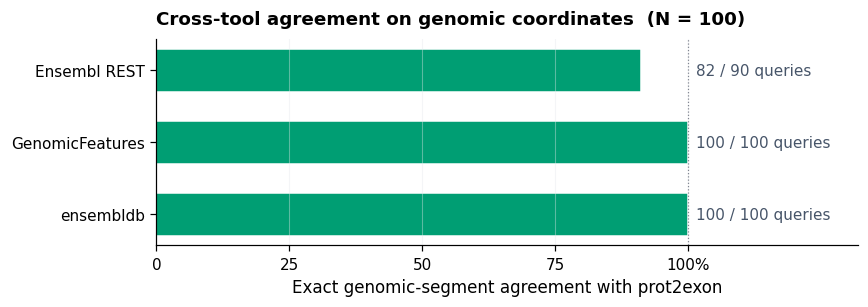

In [7]:
fig, ax = plt.subplots(figsize=(8, 2.9))
ax.barh(agreement["tool"], agreement["exact_pct"],
        color=COLORS['good'], edgecolor="white", height=0.6)
for y, (_, r) in enumerate(agreement.iterrows()):
    ax.text(101.5, y, f"{int(r['exact_match'])} / {int(r['shared_queries'])} queries",
            va="center", fontsize=10, color="#475569")
ax.set_xlim(0, 132); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"])
ax.axvline(100, ls=":", color="#0f172a", lw=0.8, alpha=0.5)
ax.set_xlabel("Exact genomic-segment agreement with prot2exon")
ax.set_title(f"Cross-tool agreement on genomic coordinates  (N = {N_QUERIES})", loc="left")
ax.grid(axis='x', alpha=0.4, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout(); plt.show()

The two Bioconductor tools match prot2exon **exactly**. The Ensembl REST
API matches on most queries; the few it misses are **off-by-one at codon-split
boundaries** (where one codon is split across two exons and the two conventions
round the boundary base differently), not structural disagreements. The
published full-scale run counts those under a 2 bp codon-split tolerance and
reports REST at 98.3 percent, with zero structural mismatches.

## The full picture

This live run uses a small `N_QUERIES` so it finishes quickly. The published
result ran the same check on a **5,000-query stratified set**, with 9 strata
chosen to stress the cases that break these tools (codon-split boundaries,
minus-strand genes, selenoproteins, incomplete CDS). prot2exon matched ensembldb
on **100.00%** of those 5,000 queries, with zero off-by-ones and zero structural
mismatches. If that full table is on disk (`validation_v86/table1.tsv`, produced
by `tutorial/reproduce_paper/benchmarks/validate_vs_ensembldb.py`) it loads below; otherwise see the
[Accuracy vs other tools](https://github.com/SotoLF/Prot2Exon/wiki/Performance-and-Benchmarking#accuracy-vs-other-tools)
wiki section.

In [8]:
full = DATA / "validation_v86" / "table1.tsv"
if full.exists():
    t = pd.read_csv(full, sep="\t")
    cols = ["category", "n", "exact_match", "off_by_one", "structural_mismatch", "exact_pct"]
    display(t[cols])
else:
    print("Full 5,000-query table not found locally; see the wiki link above.")

,category,n,exact_match,off_by_one,structural_mismatch,exact_pct
0,OVERALL,5000,5000,0,0,100.0
1,cds_incomplete,200,200,0,0,100.0
2,codon_split_boundary,500,500,0,0,100.0
3,many_exon_gene,100,100,0,0,100.0
4,minus_strand_gene,1000,1000,0,0,100.0
5,multi_exon_domain,1000,1000,0,0,100.0
6,plus_strand_gene,1000,1000,0,0,100.0
7,selenoprotein,100,100,0,0,100.0
8,single_exon_domain,1000,1000,0,0,100.0
9,single_exon_gene,100,100,0,0,100.0
